# 3.2 · Perceptrón multicapa con **ensemble** (nivel sesión)

Variante del perceptrón multicapa en la que la predicción se obtiene **promediando varias redes**
entrenadas con distinta inicialización, en lugar de emplear una única red.

**Motivo.** Durante el desarrollo se comprobó que el resultado de esta arquitectura depende de forma
apreciable de la inicialización de los pesos: una misma configuración puede variar varios puntos de
RMSE entre ejecuciones. Es el mismo fenómeno que motivó el promediado de redes en la red
convolucional, por lo que aplicarlo también aquí **elimina una asimetría metodológica** entre ambos
modelos de aprendizaje profundo y proporciona una estimación más estable.

**Todo lo demás es idéntico al perceptrón de referencia:** mismo preprocesado (normalización
acústica por sexo → eliminación del sexo → estandarización → selección de 20 variables), misma
arquitectura (una capa oculta de 16 neuronas, L2, dropout, BatchNormalization, parada temprana),
mismas particiones y mismo procedimiento de umbral.

## 0. Setup

In [1]:
import os, random
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             roc_auc_score, f1_score, accuracy_score, confusion_matrix,
                             precision_recall_fscore_support, ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow import keras
from scikeras.wrappers import KerasRegressor
import shap
tf.get_logger().setLevel('ERROR')
import warnings; warnings.filterwarnings('ignore')

from pathlib import Path
PROJECT_DIR = Path.home().as_posix() + '/Desktop/Master/UNIR_IA_TFE'   # ruta local del proyecto
path_df_features = PROJECT_DIR + '/output/df_acoustic_features_vf.csv'

c:\Users\tblxa\Desktop\Master\UNIR_IA_TFE\unir_tfm\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
##################################################
####            Constantes del modelo         ####
##################################################
PHQ_THRESHOLD = 10
RANDOM_STATE  = 42
N_CV_FOLDS    = 5

# --- ENSEMBLE ---
K_ENSEMBLE = 5      # nº de redes promediadas (mismo valor que en la red convolucional)

# --- arquitectura (idéntica al MLP de referencia) ---
MLP_K         = 20
MLP_HIDDEN    = (16,)
MLP_L2        = 1e-2
MLP_DROPOUT   = 0.4
MLP_LR        = 1e-3
MLP_ACT       = 'relu'
MLP_BATCHNORM = True
MLP_BATCH     = 16
MLP_EPOCHS    = 300
MLP_PATIENCE  = 30
MLP_VAL_SPLIT = 0.2

COLS_EXCLUDE = ['participant_id', 'phq8_binary', 'path_audio',
                'path_transcript', 'split', 'durAudio', 'durSession']
TARGET = 'phq8_score'
ACOUSTIC_PREFIXES = ('f0_', 'energy_', 'mfcc', 'centroid_', 'bandwidth_',
                     'rolloff_', 'zcr_', 'hnr_', 'jitter_', 'shimmer_')

np.random.seed(RANDOM_STATE); random.seed(RANDOM_STATE); tf.random.set_seed(RANDOM_STATE)

## 1. Datos y particiones

In [3]:
df = pd.read_csv(path_df_features)
COLS_FEATURES = [c for c in df.columns if c not in COLS_EXCLUDE + [TARGET]]
ACOUSTIC_COLS = [c for c in COLS_FEATURES if c.startswith(ACOUSTIC_PREFIXES)]

df_td = df[df['split'].isin(['train', 'dev'])].reset_index(drop=True)
df_te = df[df['split'] == 'test'].reset_index(drop=True)
X_td, y_td = df_td[COLS_FEATURES], df_td[TARGET]
X_te, y_te = df_te[COLS_FEATURES], df_te[TARGET]
y_td_bin = (y_td >= PHQ_THRESHOLD).astype(int)
y_te_bin = (y_te >= PHQ_THRESHOLD).astype(int)

cv_splits = list(StratifiedKFold(N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
                 .split(X_td, y_td_bin))
print(f"Train+Dev {len(X_td)} sesiones ({y_td_bin.sum()} con sintomatología) | Test {len(X_te)} ({y_te_bin.sum()})")
print(f"Ensemble de {K_ENSEMBLE} redes")

Train+Dev 140 sesiones (43 con sintomatología) | Test 46 (14)
Ensemble de 5 redes


## 2. Pipeline y construcción del ensemble

In [4]:
class GenderZScoreScaler(BaseEstimator, TransformerMixin):
    """Z-score de las variables acústicas dentro de cada grupo de sexo (sin fuga en CV)."""
    def __init__(self, cols, gender_col='gender'):
        self.cols = cols; self.gender_col = gender_col
    def fit(self, X, y=None):
        self.stats_ = {}
        for g, sub in X.groupby(self.gender_col):
            self.stats_[g] = (sub[self.cols].mean(), sub[self.cols].std(ddof=0).replace(0, 1.0))
        self.global_ = (X[self.cols].mean(), X[self.cols].std(ddof=0).replace(0, 1.0))
        return self
    def transform(self, X):
        X = X.copy()
        for g, idx in X.groupby(self.gender_col).groups.items():
            mu, sd = self.stats_.get(g, self.global_)
            X.loc[idx, self.cols] = (X.loc[idx, self.cols] - mu) / sd
        return X

class DropColumns(BaseEstimator, TransformerMixin):
    def __init__(self, cols): self.cols = cols
    def fit(self, X, y=None): return self
    def transform(self, X): return X.drop(columns=[c for c in self.cols if c in X.columns])

def build_keras_model(n_features, hidden_units=MLP_HIDDEN, dropout=MLP_DROPOUT,
                      l2=MLP_L2, learning_rate=MLP_LR, activation=MLP_ACT,
                      batchnorm=MLP_BATCHNORM):
    """Red densa regularizada para regresión del PHQ-8 (idéntica a la del MLP de referencia)."""
    reg = keras.regularizers.l2(l2) if l2 else None
    m = keras.Sequential(name='mlp_phq8')
    m.add(keras.layers.Input(shape=(n_features,)))
    for u in hidden_units:
        m.add(keras.layers.Dense(u, kernel_regularizer=reg))
        if batchnorm: m.add(keras.layers.BatchNormalization())
        m.add(keras.layers.Activation(activation))
        if dropout: m.add(keras.layers.Dropout(dropout))
    m.add(keras.layers.Dense(1, activation='linear'))
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss='mse')
    return m

def build_member(seed):
    """Un miembro del ensemble: pipeline completo con una semilla concreta."""
    reg = KerasRegressor(
        model=build_keras_model, model__n_features=MLP_K,
        epochs=MLP_EPOCHS, batch_size=MLP_BATCH, validation_split=MLP_VAL_SPLIT,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=MLP_PATIENCE,
                                                 restore_best_weights=True)],
        verbose=0, random_state=seed)
    return Pipeline([
        ('gender',     GenderZScoreScaler(ACOUSTIC_COLS)),
        ('dropgender', DropColumns(['gender'])),
        ('scaler',     StandardScaler()),
        ('select',     SelectKBest(f_regression, k=MLP_K)),
        ('mlp',        reg),
    ])

def fit_ensemble(X, y):
    """Entrena K redes con distinta inicialización sobre los mismos datos."""
    ms = []
    for k in range(K_ENSEMBLE):
        keras.utils.set_random_seed(RANDOM_STATE + k)
        ms.append(build_member(RANDOM_STATE + k).fit(X, y))
    return ms

def predict_ensemble(models, X):
    """Predicción del ensemble: media de las predicciones de sus miembros."""
    return np.mean([np.asarray(m.predict(X)).ravel() for m in models], axis=0)

## 3. Validación cruzada y ajuste del umbral
En cada partición se entrena el ensemble completo y se promedian sus predicciones, obteniendo así
una predicción *out-of-fold* por sesión con la que se ajusta el umbral de decisión.

In [5]:
oof = np.zeros(len(X_td))
rmse_f, mae_f, r2_f = [], [], []
for i, (tr, va) in enumerate(cv_splits, 1):
    ms = fit_ensemble(X_td.iloc[tr], y_td.iloc[tr])
    p = predict_ensemble(ms, X_td.iloc[va])
    oof[va] = p
    rmse_f.append(np.sqrt(mean_squared_error(y_td.iloc[va], p)))
    mae_f.append(mean_absolute_error(y_td.iloc[va], p))
    r2_f.append(r2_score(y_td.iloc[va], p))
    print(f"  fold {i}/{N_CV_FOLDS}: RMSE {rmse_f[-1]:.3f}")

print(f"\n── Evaluación CV ({N_CV_FOLDS}-fold estratificada) ──")
print(f"{'RMSE':<6} {np.mean(rmse_f):>7.3f}  ± {np.std(rmse_f):.3f}")
print(f"{'MAE':<6} {np.mean(mae_f):>7.3f}  ± {np.std(mae_f):.3f}")
print(f"{'R²':<6} {np.mean(r2_f):>7.3f}  ± {np.std(r2_f):.3f}")

ths = np.linspace(oof.min(), oof.max(), 200)
f1_curve = [f1_score(y_td_bin, (oof >= t).astype(int), zero_division=0) for t in ths]
best_thr = ths[int(np.argmax(f1_curve))]
print(f"\nUmbral óptimo (OOF): {best_thr:.2f}  |  F1 OOF {max(f1_curve):.3f}")

  fold 1/5: RMSE 4.389
  fold 2/5: RMSE 5.198
  fold 3/5: RMSE 6.213
  fold 4/5: RMSE 6.117
  fold 5/5: RMSE 6.948

── Evaluación CV (5-fold estratificada) ──
RMSE     5.773  ± 0.888
MAE      4.479  ± 0.660
R²      -0.080  ± 0.180

Umbral óptimo (OOF): 5.62  |  F1 OOF 0.506


## 4. Modelo final y evaluación en test

In [6]:
models_final = fit_ensemble(X_td, y_td)
p_te = predict_ensemble(models_final, X_te)

print('── REGRESIÓN (test) ──')
print(f"  RMSE {np.sqrt(mean_squared_error(y_te, p_te)):.3f} | "
      f"MAE {mean_absolute_error(y_te, p_te):.3f} | R² {r2_score(y_te, p_te):.3f}")
print('\n── CLASIFICACIÓN DERIVADA (test) ──')
print(f"  AUC {roc_auc_score(y_te_bin, p_te):.3f}")
_, _, bf, _ = precision_recall_fscore_support(y_te_bin, np.ones(len(y_te_bin)),
                                              average='binary', zero_division=0)
print(f"  Línea base trivial (marcar a todos): F1 {bf:.3f}")
for nom, t in [('nominal (>=10)', PHQ_THRESHOLD), (f'óptimo OOF ({best_thr:.2f})', best_thr)]:
    yh = (p_te >= t).astype(int)
    pr, rc, f_, _ = precision_recall_fscore_support(y_te_bin, yh, average='binary', zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_te_bin, yh).ravel()
    print(f"  [{nom:<22}] Prec {pr:.3f} Rec {rc:.3f} F1 {f_:.3f} Acc {accuracy_score(y_te_bin,yh):.3f}"
          f"  TP {tp} FP {fp} FN {fn} TN {tn}")
print('\n  Referencia: MLP sin ensemble AUC 0.636 / F1 0.500 · RF AUC 0.743 / F1 0.509')

── REGRESIÓN (test) ──
  RMSE 6.562 | MAE 5.199 | R² -0.048

── CLASIFICACIÓN DERIVADA (test) ──
  AUC 0.663
  Línea base trivial (marcar a todos): F1 0.467
  [nominal (>=10)        ] Prec 0.500 Rec 0.071 F1 0.125 Acc 0.696  TP 1 FP 1 FN 13 TN 31
  [óptimo OOF (5.62)     ] Prec 0.450 Rec 0.643 F1 0.529 Acc 0.652  TP 9 FP 11 FN 5 TN 21

  Referencia: MLP sin ensemble AUC 0.636 / F1 0.500 · RF AUC 0.743 / F1 0.509


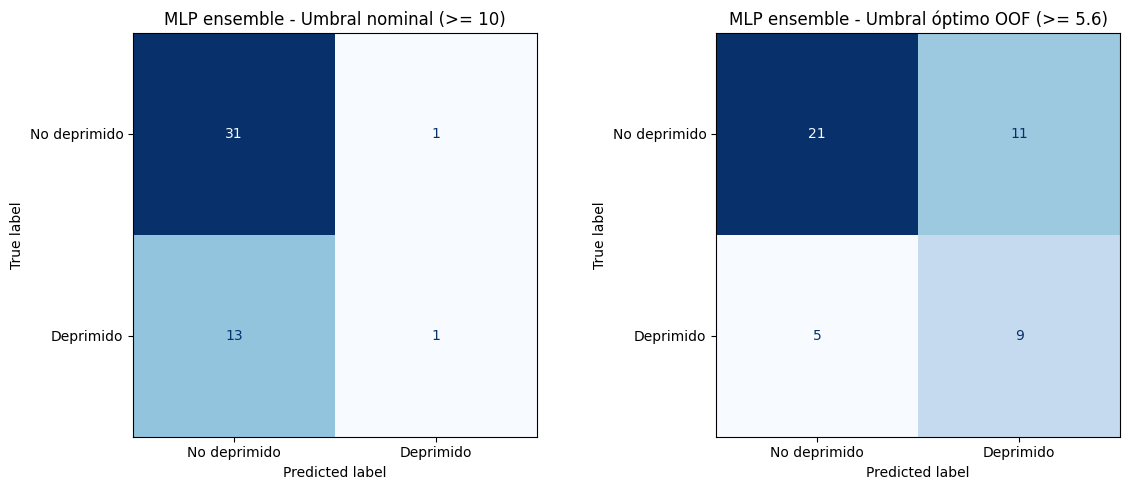

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, t, ttl in [(axes[0], PHQ_THRESHOLD, f'Umbral nominal (>= {PHQ_THRESHOLD})'),
                   (axes[1], best_thr, f'Umbral óptimo OOF (>= {best_thr:.1f})')]:
    ConfusionMatrixDisplay.from_predictions(y_te_bin, (p_te >= t).astype(int),
        display_labels=['No deprimido', 'Deprimido'], colorbar=False, ax=ax, cmap='Blues')
    ax.set_title(f'MLP ensemble - {ttl}')
plt.tight_layout(); plt.show()

## 5. Interpretabilidad — DeepSHAP sobre el ensemble
Se calculan los valores SHAP de cada red del ensemble y se **promedian**, de forma coherente con el
modo en que se obtiene la predicción. Todas las redes comparten el mismo preprocesado y, por tanto,
las mismas 20 variables.

shap_values: (46, 20) | variables: 20


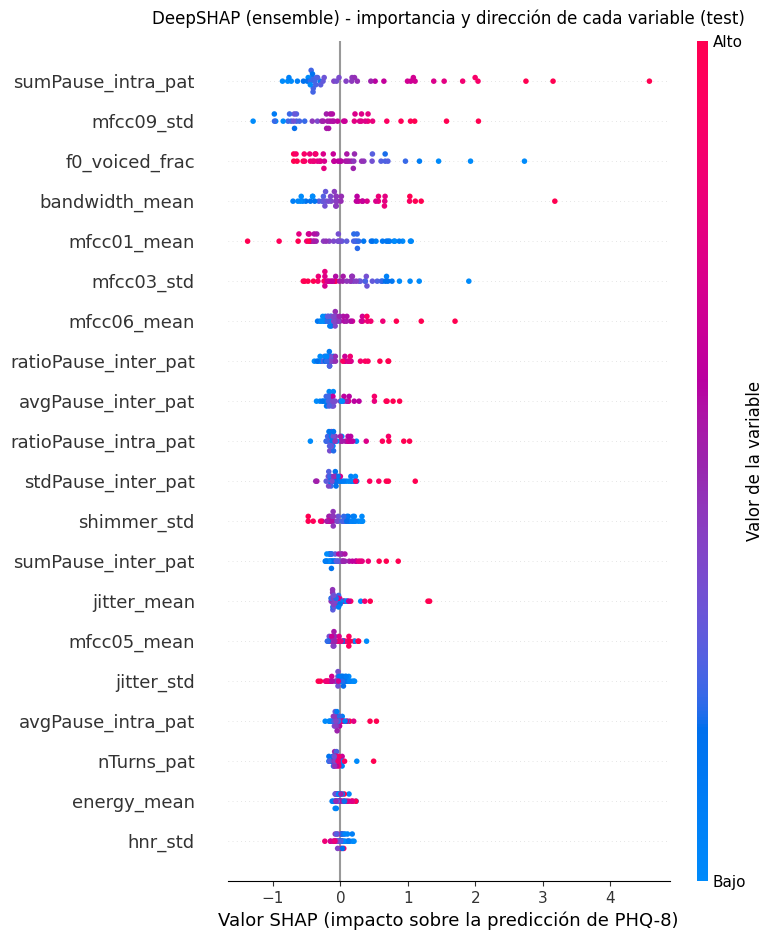

In [8]:
m0 = models_final[0]
gender_f = m0.named_steps['gender']; drop_f = m0.named_steps['dropgender']
scaler_f = m0.named_steps['scaler'];  sel_f  = m0.named_steps['select']

def _transform(X):
    return np.asarray(sel_f.transform(scaler_f.transform(
        drop_f.transform(gender_f.transform(X))))).astype(np.float32)

X_td_t, X_te_t = _transform(X_td), _transform(X_te)
cols_after_drop = [c for c in COLS_FEATURES if c != 'gender']
feat_names = [c for c, k in zip(cols_after_drop, sel_f.get_support()) if k]

rng = np.random.RandomState(RANDOM_STATE)
bg = X_td_t[rng.choice(len(X_td_t), size=min(100, len(X_td_t)), replace=False)]

sv_list = []
for m in models_final:
    e = shap.DeepExplainer(m.named_steps['mlp'].model_, bg)
    sv = e.shap_values(X_te_t, check_additivity=False)
    sv = sv[0] if isinstance(sv, list) else sv
    sv = np.asarray(sv)
    if sv.ndim == 3: sv = sv[:, :, 0]
    sv_list.append(sv)
shap_values = np.mean(sv_list, axis=0)     # promedio sobre el ensemble

X_te_df = pd.DataFrame(X_te_t, columns=feat_names)
print('shap_values:', shap_values.shape, '| variables:', len(feat_names))

plt.figure()
shap.summary_plot(shap_values, X_te_df, plot_type='dot', max_display=20, show=False)
# rotulos en castellano (la libreria SHAP los genera en ingles)
_fig = plt.gcf()
plt.gca().set_xlabel('Valor SHAP (impacto sobre la predicción de PHQ-8)')
for _a in _fig.axes[1:]:
    if _a.get_ylabel() == 'Feature value':
        _a.set_ylabel('Valor de la variable')
        if len(_a.get_yticklabels()) == 2:
            _a.set_yticklabels(['Bajo', 'Alto'])
plt.title('DeepSHAP (ensemble) - importancia y dirección de cada variable (test)', pad=12)
plt.tight_layout(); plt.show()

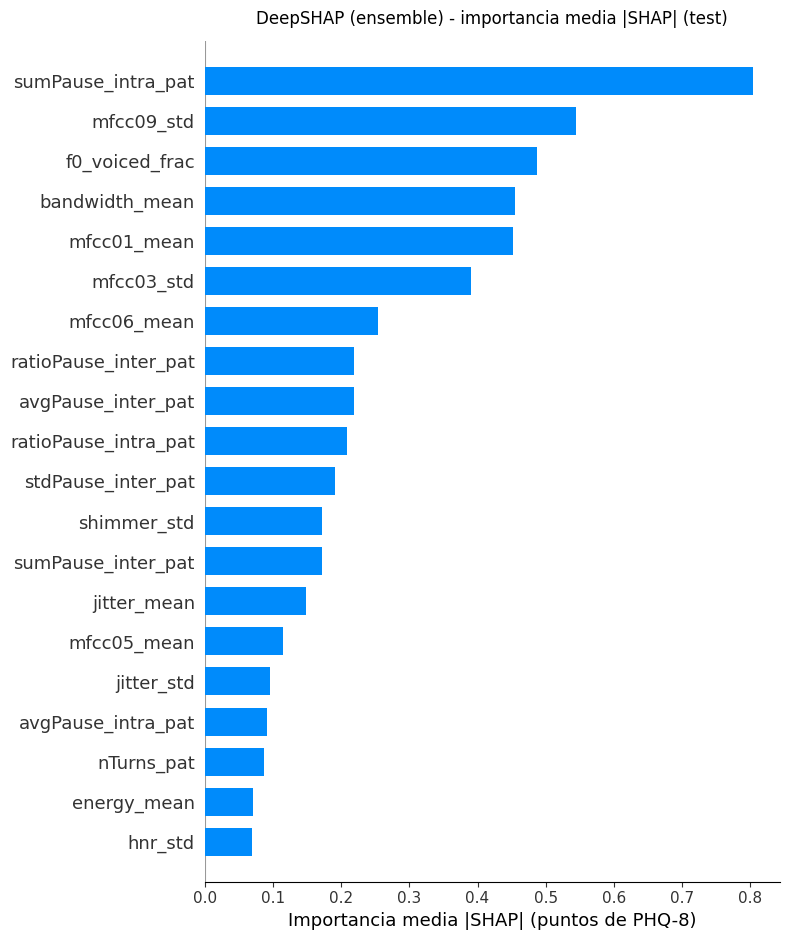

In [9]:
plt.figure()
shap.summary_plot(shap_values, X_te_df, plot_type='bar', max_display=20, show=False)
# rotulo en castellano (la libreria SHAP lo genera en ingles)
plt.gca().set_xlabel('Importancia media |SHAP| (puntos de PHQ-8)')
plt.title('DeepSHAP (ensemble) - importancia media |SHAP| (test)', pad=12)
plt.tight_layout(); plt.show()